                                            Spam Mail Prediction Project Analysis 

A Spam Mail Prediction Project is a simple ML project that basically identifies whether a email is spam or ham. 

A Spam mail is basically a type of mail, which is more of a type of fraud and unwanted mail whereas ham is a type of mail which basically means that it is a type of ham, or not spam. 

In [1]:
import numpy as np 
import pandas as pd 
import string  
import matplotlib.pyplot as plt    
import seaborn as sns 

In [2]:
data = pd.read_csv("mail_data.csv") 
data 
# Here, we have loaded the dataset 

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
data.describe() 

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
data.shape 
# Here the shape of the data is getting printed 

(5572, 2)

In [6]:
data.isnull().sum()  

# Here as we can see that there are no empty values in the whole dataset 

Category    0
Message     0
dtype: int64

In [7]:
data["Category"].unique() 

# Here as we can see that there are only 2 unique values 

array(['ham', 'spam'], dtype=object)

Conversion of the categorical values to the numeric values has to be taken place. 

In [8]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder() 

for col in ["Category"]: 
    data[col] = le.fit_transform(data[col]) 

data 

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In the above code as we can see that spam has been coonverted to 1 and ham ahs been converted to 0 

Now, the process of the Text Preprocessing of the functions take place. In this ml project, its necessary to use: 

 1. Lowercase Conversion 
 2. Removes punctuation 
 3. Removes stopwords using sklearn 

All the above process is necessary to perform as because: 

1. Lowercase helps in removing the duplicate features.

2. Removing the punctuation as removing the punctuation helps in spam detection. 

3. Removing the stopwords is also necessary in the spam prediction project as the stop words can be same in both cases. 

In [9]:
# the steps of pre processing include: 
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS 

def preprocess_text(text): 
    text = text.lower() 

    # Removing the punctuation marks 
    text = "".join([char for char in text if char not in string.punctuation])  

    words = text.split() 

    # Remoove stopwords 

    words = [word for word in words if word not in ENGLISH_STOP_WORDS] 

    return " ".join(words) 

In [10]:
data['clean_message'] = data['Message'].apply(preprocess_text) 

data 

,Category,Message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,2nd time tried 2 contact u u won £750 pound pr...
5568,0,Will ü b going to esplanade fr home?,ü b going esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestions
5570,0,The guy did some bitching but I acted like i'd...,guy did bitching acted like id interested buyi...


Here, we need to convert the text into numbers ad hencce we require the TfidfVectorizer library from the sklearn library for the further prerocessing. 

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer 

tfidf = TfidfVectorizer(max_features = 3000) 

tfidf 

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [12]:
x = tfidf.fit_transform(data['clean_message']).toarray() 
x 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 3000))

In [13]:
y = data.filter(['Category'], axis = 1)  
y 

,Category
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [14]:
# Now, we will apply train, test and spliton the model for the further preprocessing as; 

from sklearn.model_selection import train_test_split 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =  42) 

In [15]:
x_train 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4457, 3000))

In [16]:
x_test 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1115, 3000))

In [17]:
y_train 

,Category
1978,1
3989,0
3935,0
4078,0
4086,1
...,...
3772,0
5191,0
5226,0
5390,0


In [18]:
y_test 

,Category
3245,0
944,0
1044,0
2484,0
812,0
...,...
4264,0
2439,0
5556,0
4205,0


Here, we will be using the multinomial naive byes instead of other models as the naive byes work much more perfectly in case of words and also of the probability of words. Basically, its the best for NLP and spam classification related things. 

In [19]:
from sklearn.naive_bayes import MultinomialNB  

model = MultinomialNB() 
a = model.fit(x_train, y_train) 
a 

c:\Users\91981\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [20]:
y_pred =  a.predict(x_test) 
y_pred  

# Predictions have been msde on the x_test data 

array([0, 0, 0, ..., 0, 0, 0], shape=(1115,))

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 

# It shows around 98% accuracy 


Accuracy: 0.9811659192825112

Confusion Matrix:
 [[966   0]
 [ 21 128]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# Plotting Visualixations 

Now, comes an important part of plotting the visualizations and hence we will be plotting the Confusion matrix and also the correlation heatmap. 

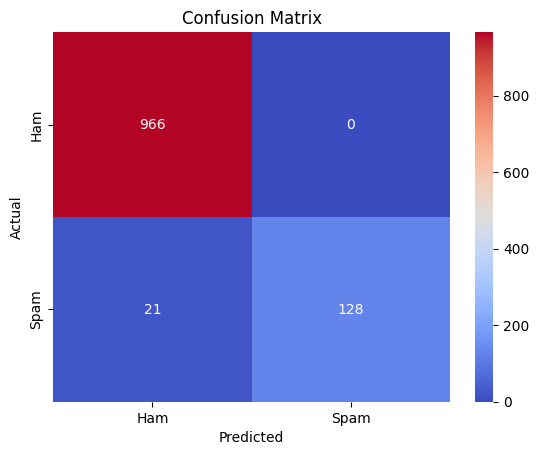

In [22]:
# Confusion matric  
cm  = confusion_matrix(y_test, y_pred) 

sns.heatmap(cm, annot  = True, fmt = 'd', cmap = "coolwarm", 
            xticklabels = ["Ham", "Spam"],
            yticklabels = ["Ham", "Spam"])  
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.title("Confusion Matrix") 
plt.show() 

Now, comes the plotting of the heatmap on to the plot. First we convert TF-IDF to the DataFrame. 

Then, we will have to select the top important words form the set and at last we will do the plotting of the heatmap. 

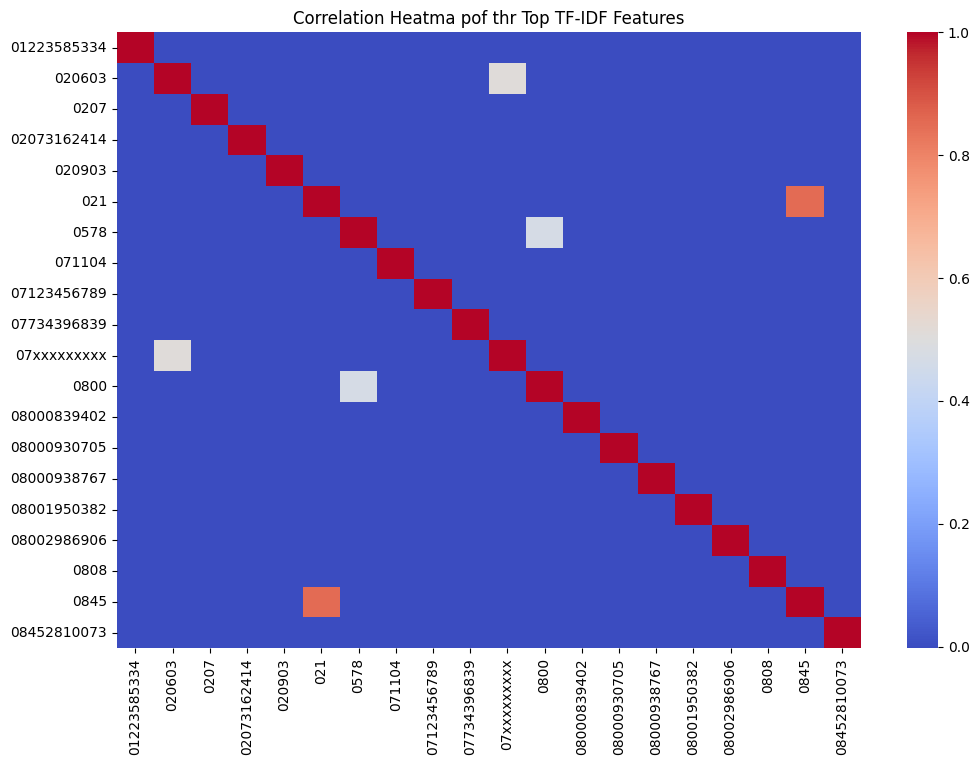

In [23]:
tfidf_df = pd.DataFrame(x, columns=tfidf.get_feature_names_out()) 

# Selection of the top features will be done as:  

top_words = tfidf_df.iloc[:, :20] 
# Here, basically this means that the top features have been selected from the above dataset as it helps in creating a reaadable plot 

plt.figure(figsize = (12,8)) 
sns.heatmap(top_words.corr(), cmap = "coolwarm") 
plt.title("Correlation Heatma pof thr Top TF-IDF Features") 
plt.show() 

The above heatmap basically shows that how the 2 words are related strongly in messages. 

Dark Color : Strong relationship
Light Color : weak relationship 

# Prediction Function 
Now, we will be creating a prediction function 

In [24]:
def predict_spam(message): 
    cleaned = preprocess_text(message) 

    vector =  tfidf.transform([cleaned]).toarray() 

    prediction = a.predict(vector)  

    if prediction[0] == 1:
        return "Spam ❌"
    else:
        return "Not Spam and a Ham mail ✔️"

In [25]:
print(predict_spam("Congratulations! You won a free lottery ticket"))

Spam ❌


In [26]:
print(predict_spam("Hey, are we meeting today?")) 

Not Spam and a Ham mail ✔️


In [27]:
print(predict_spam("You have won a prixe. Please collect it.")) 

Spam ❌


In [28]:
print(predict_spam("Your meeting is scheduled for 6 pm."))  

Not Spam and a Ham mail ✔️
